# Experiment No. – 5

## Program
Analyze the impact of Bagging, Boosting, and Stacking on Decision Tree performance using the Pima Diabetes dataset.

## Aim
To evaluate the impact of ensemble methods—Bagging, Boosting, and Stacking—on the performance of a Decision Tree classifier using the Pima Diabetes dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [3]:
data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

Number of rows: 768
Number of columns: 9


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Check Zero Value

In [8]:
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for column in columns_with_zero:
    print(column, ":", (data[column] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [9]:
data[columns_with_zero] = data[columns_with_zero].replace(0, np.nan)

data.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [10]:
for column in columns_with_zero:
    data[column] = data[column].fillna(data[column].median())

In [11]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
x = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [13]:
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


Train/Test Split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


Standardize Features

In [16]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Baseline Decision Tree

In [17]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Predict Using Decision Tree

In [18]:
y_pred_dt = dt_model.predict(x_test_scaled)

y_pred_dt

array([1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

Decision Tree Accuracy

In [19]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", dt_accuracy * 100)

Decision Tree Accuracy: 0.6818181818181818
Decision Tree Accuracy (%): 68.18181818181817


Bagging

In [21]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, #it mean we use 100 DT
    random_state=42
)

Train Bagging Model

In [22]:
bagging_model.fit(x_train_scaled, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


Predict Using Bagging

In [23]:
y_pred_bagging = bagging_model.predict(x_test_scaled)

Bagging Accuracy

In [24]:
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)

print("Bagging Accuracy:", bagging_accuracy)
print("Bagging Accuracy (%):", bagging_accuracy * 100)

Bagging Accuracy: 0.7272727272727273
Bagging Accuracy (%): 72.72727272727273


Boosting

In [25]:
boosting_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)

Train Boosting Model

In [26]:
boosting_model.fit(x_train_scaled, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


Predict Using Boosting

In [27]:
y_pred_boosting = boosting_model.predict(x_test_scaled)

Boosting Accuracy

In [28]:
boosting_accuracy = accuracy_score(y_test, y_pred_boosting)

print("Boosting Accuracy:", boosting_accuracy)
print("Boosting Accuracy (%):", boosting_accuracy * 100)

Boosting Accuracy: 0.7597402597402597
Boosting Accuracy (%): 75.97402597402598


Stacking

In [29]:
base_learners = [
    ("tree1", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    )),
    
    ("tree2", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    )),
    
    ("tree3", DecisionTreeClassifier(
        max_depth=7,
        random_state=42
    ))
]

Create Stacking Model

In [30]:
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    cv=5
)

Train Stacking Model

In [31]:
stacking_model.fit(x_train_scaled, y_train)

,estimators,"[('tree1', ...), ('tree2', ...), ...]"
,final_estimator,DecisionTreeC...ndom_state=42)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2


Predict Using Stacking

In [32]:
y_pred_stacking = stacking_model.predict(x_test_scaled)

Stacking Accuracy

In [33]:
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)

print("Stacking Accuracy:", stacking_accuracy)
print("Stacking Accuracy (%):", stacking_accuracy * 100)

Stacking Accuracy: 0.7207792207792207
Stacking Accuracy (%): 72.07792207792207


Compare All Models

In [34]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bagging",
        "Boosting",
        "Stacking"
    ],
    
    "Accuracy": [
        dt_accuracy,
        bagging_accuracy,
        boosting_accuracy,
        stacking_accuracy
    ]
})

results

,Model,Accuracy
0,Decision Tree,0.681818
1,Bagging,0.727273
2,Boosting,0.759740
3,Stacking,0.720779


Accuracy in Percentage

In [35]:
results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Model,Accuracy,Accuracy (%)
0,Decision Tree,0.681818,68.181818
1,Bagging,0.727273,72.727273
2,Boosting,0.759740,75.974026
3,Stacking,0.720779,72.077922


Visualization

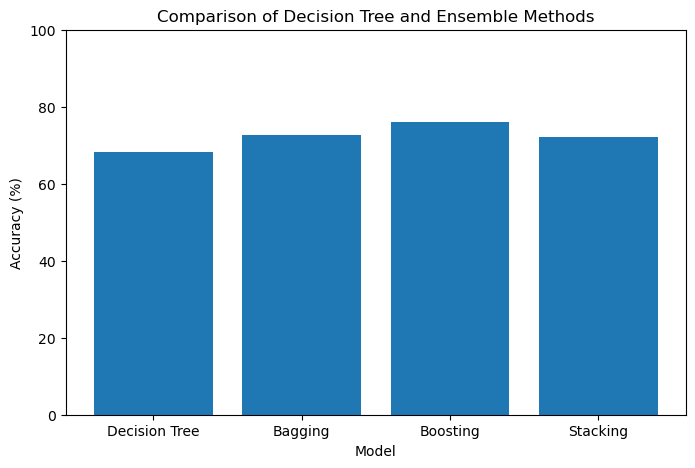

In [36]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Decision Tree and Ensemble Methods")

plt.ylim(0, 100)
plt.show()

Find Accuracy Values

In [37]:
for index, row in results.iterrows():
    print(row["Model"], ":", round(row["Accuracy (%)"], 2), "%")

Decision Tree : 68.18 %
Bagging : 72.73 %
Boosting : 75.97 %
Stacking : 72.08 %


Improvement Over Decision Tree

In [38]:
results["Improvement over Decision Tree (%)"] = (
    results["Accuracy (%)"] - dt_accuracy * 100
)

results

,Model,Accuracy,Accuracy (%),Improvement over Decision Tree (%)
0,Decision Tree,0.681818,68.181818,0.000000
1,Bagging,0.727273,72.727273,4.545455
2,Boosting,0.759740,75.974026,7.792208
3,Stacking,0.720779,72.077922,3.896104


Final Comparison

In [39]:
print("Decision Tree Accuracy :", round(dt_accuracy * 100, 2), "%")
print("Bagging Accuracy       :", round(bagging_accuracy * 100, 2), "%")
print("Boosting Accuracy      :", round(boosting_accuracy * 100, 2), "%")
print("Stacking Accuracy      :", round(stacking_accuracy * 100, 2), "%")

Decision Tree Accuracy : 68.18 %
Bagging Accuracy       : 72.73 %
Boosting Accuracy      : 75.97 %
Stacking Accuracy      : 72.08 %


## Conclusion

The experiment compared a standalone Decision Tree with three ensemble learning techniques: Bagging, Boosting, and Stacking using the Pima Indians Diabetes dataset.

The Decision Tree was used as the baseline model. Bagging combined multiple Decision Trees to reduce variance and improve robustness. AdaBoost trained weak learners sequentially to focus on incorrectly classified samples. Stacking combined multiple Decision Trees with a Decision Tree as the meta-estimator.

The accuracy results showed the effect of ensemble learning on the baseline Decision Tree. The performance of each method was compared using test-set accuracy.